# Star Type Classification

For comparing all models of ML
It can be used for prediction

``` txt
Temperature -- K
L -- L/Lo
R -- R/Ro
AM -- Mv
Color -- General Color of Spectrum
Spectral_Class -- O,B,A,F,G,K,M / SMASS - <https://en.wikipedia.org/wiki/Asteroid_spectral_types>
Type -- Red Dwarf, Brown Dwarf, White Dwarf, Main Sequence , Super Giants, Hyper Giants
```

TARGET:
Type

from 0 to 5

- Red Dwarf - 0
- Brown Dwarf - 1
- White Dwarf - 2
- Main Sequence - 3
- Super Giants - 4
- Hyper Giants - 5

MATH:

- Lo = 3.828 x 10^26 Watts
(Avg Luminosity of Sun)
- Ro = 6.9551 x 10^8 m
(Avg Radius of Sun)

COLUMNS:

- Temperature(K)
- L: Relative Luminosity
- R: Relative Radius
- A_M: Absolute Magnitude
- Color: General Obs. Color
- Spectral_Class: SMASS Spec.
- Type: Type One-Hot from 0 - 5

In [69]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import train_test_split

from sklearn.ensemble import (
    VotingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import LabelEncoder, StandardScaler

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from uuid import uuid4
import pandas as pd
import numpy as np

from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)

plt.style.use('bmh')
mpl.rcParams['text.color'] = 'w'
pd.options.mode.chained_assignment = None


## Read

        Temperature              L            R         A_M        Type
count    240.000000     240.000000   240.000000  240.000000  240.000000
mean   10497.462500  107188.361635   237.157781    4.382396    2.500000
std     9552.425037  179432.244940   517.155763   10.532512    1.711394
min     1939.000000       0.000080     0.008400  -11.920000    0.000000
25%     3344.250000       0.000865     0.102750   -6.232500    1.000000
50%     5776.000000       0.070500     0.762500    8.313000    2.500000
75%    15055.500000  198050.000000    42.750000   13.697500    4.000000
max    40000.000000  849420.000000  1948.500000   20.060000    5.000000


,Temperature,L,R,A_M,Color,Spectral_Class,Type
0,3068,0.002400,0.1700,16.12,Red,M,0
1,3042,0.000500,0.1542,16.60,Red,M,0
2,2600,0.000300,0.1020,18.70,Red,M,0
3,2800,0.000200,0.1600,16.65,Red,M,0
4,1939,0.000138,0.1030,20.06,Red,M,0


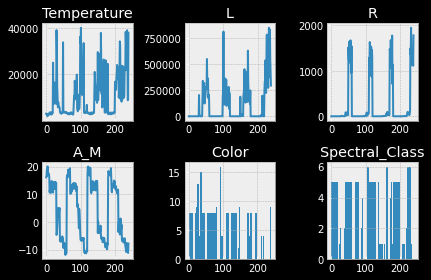

In [70]:
df = pd.read_csv('/home/zau/Desktop/UFRN_S/TAP3_2021.1/data/star/Stars.csv')

fig, axes = plt.subplots(2, 3)

count = 0
for ax in axes.flat:
    if count < 4:
        col = df.columns[count]
        df.loc[:, col].plot(ax=ax, title=col)
        count += 1
    elif count < 8:
        col = df.columns[count]
        __x = df.loc[:, col].index.tolist()
        __y = df.loc[:, col].astype('category').cat.codes
        ax.bar(__x, __y)
        ax.set_title(col)
        count += 1


fig.tight_layout()

print(df.describe())
df.head()

## Pre-processing

,Temperature,L,R,A_M,Color,Spectral_Class
0,-0.779382,-0.598624,-0.459210,1.116745,8,5
1,-0.782110,-0.598624,-0.459241,1.162414,8,5
2,-0.828477,-0.598624,-0.459342,1.362213,8,5
3,-0.807496,-0.598624,-0.459229,1.167171,8,5
4,-0.897819,-0.598624,-0.459340,1.491607,8,5


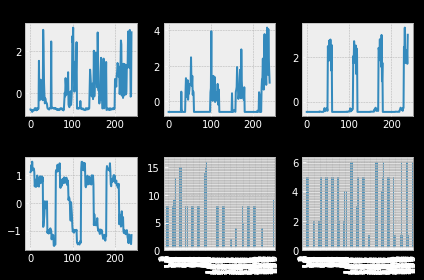

In [6]:
col_numeric = ['Temperature', 'L', 'R', 'A_M']
col_label = ['Color', 'Spectral_Class']

X = df[col_numeric+col_label]
y = df[['Type']]

for col in col_label:
    X.loc[:,[col]] = LabelEncoder().fit_transform(X[col])
    
for col in col_numeric:
    X.loc[:,[col]] = StandardScaler().fit_transform(X[col].values.reshape(-1, 1))

fig, axes = plt.subplots(2, 3)

# plot counter
count=0
for ax in axes.flat:
    if count < 4:
        col = X.columns[count]
        X.loc[:,col].plot(ax=ax, title=col)
        count+=1
    elif count < 8:
        col = X.columns[count]
        X.loc[:,col].plot.bar(ax=ax, title=col)
        count+=1


fig.tight_layout()
    
X.head()


## Data


In [7]:

x_train, x_test, y_train, y_test = train_test_split(
    X.values,
    y.values,
    test_size=0.25,
    shuffle=False
)

y_train = y_train.ravel()

print("X.shape = {}".format(X.shape))
print("y.shape = {}".format(y.shape))
print("x_train.shape = {}".format(x_train.shape))
print("y_train.shape = {}".format(y_train.shape))
print("x_test.shape = {}".format(x_test.shape))
print("y_test.shape = {}".format(y_test.shape))


X.shape = (240, 6)
y.shape = (240, 1)
x_train.shape = (180, 6)
y_train.shape = (180,)
x_test.shape = (60, 6)
y_test.shape = (60, 1)


In [8]:
def plot_original_data():
    plt.plot(x_test, y_test, 'o', color='red')

def plot_predicted_data(pred):
    plt.plot(x_test, pred, 'x', alpha=0.6, color='blue')
    plt.legend(handles=[
        mpatches.Patch(color='red', label='Original data'),
        mpatches.Patch(color='blue', label='Predicted data'),
    ])

## Test Classifier's

### KNN

Text(0.5, 1.0, 'KNN - Score 0.9')

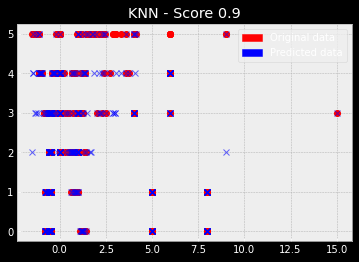

In [71]:
plot_original_data()

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train.ravel())

pred = model.predict(x_test)
knnScore = model.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("KNN - Score {}".format(knnScore))


### NV

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


Text(0.5, 1.0, 'Naive Bayes - Score 0.9833333333333333')

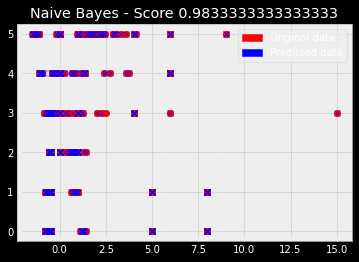

In [72]:
plot_original_data()

model = GaussianNB()
model.fit(x_train, y_train.ravel())
print(model.class_prior_)
pred = model.predict(x_test)
naiveBayesScore = model.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("Naive Bayes - Score {}".format(naiveBayesScore))


### Decision Tree

Text(0.5, 1.0, 'Decision Tree - Score 0.6666666666666666')

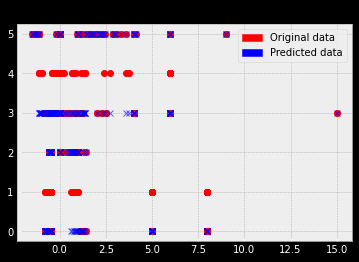

In [11]:
plot_original_data()

model = DecisionTreeClassifier(
    random_state=0, criterion="entropy", max_depth=2)
model.fit(x_train, y_train.ravel())

pred = model.predict(x_test)
treeScore = model.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("Decision Tree - Score {}".format(treeScore))


### MLP

Text(0.5, 1.0, 'MLP - Score 1.0')

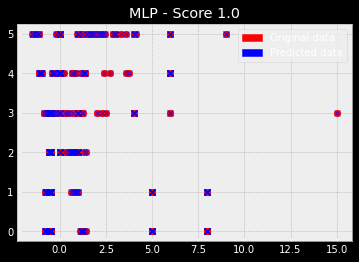

In [73]:
plot_original_data()

model = MLPClassifier(random_state=1,
                      max_iter=100000,
                      hidden_layer_sizes=(10, 10))
model.fit(x_train, y_train.ravel())

pred = model.predict(x_test)
mlpScore = model.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("MLP - Score {}".format(mlpScore))


### SVM

Text(0.5, 1.0, 'SVM - Score 0.8666666666666667')

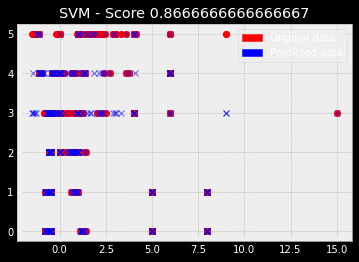

In [74]:
plot_original_data()

model = SVC(gamma='auto')
model.fit(x_train, y_train.ravel())

pred = model.predict(x_test)
svmScore = model.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("SVM - Score {}".format(svmScore))


### AD

Text(0.5, 1.0, 'AD - Score 0.6666666666666666')

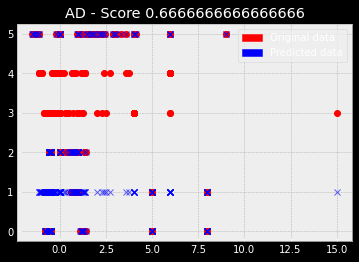

In [75]:
plot_original_data()

model = AdaBoostClassifier(n_estimators=100, random_state=0)
model.fit(x_train, y_train.ravel())

pred = model.predict(x_test)
adScore = model.score(x_test, y_test)

plot_predicted_data(pred)
plt.title("AD - Score {}".format(adScore))


### Bar Score's

[0.9, 0.9833333333333333, 0.6666666666666666, 1.0, 0.6666666666666666, 0.8666666666666667]


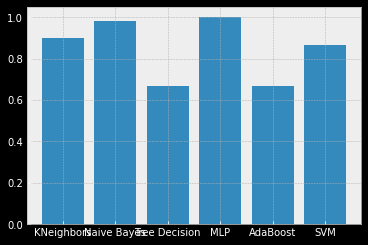

In [15]:
height = [knnScore, naiveBayesScore, treeScore, mlpScore, adScore, svmScore]
bars = ('KNeighbors', 'Naive Bayes', 'Tree Decision', 'MLP', 'AdaBoost', 'SVM')
x_pos = np.arange(len(bars))
 
print(height)
plt.bar(x_pos, height)
plt.xticks(x_pos, bars)
plt.show()

## Ensemble's

### Parms

In [16]:
knn_parms = ParameterGrid({
    'n_neighbors': [2, 3, 5],
    'p': [1, 2],
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree']
})

ad_parms = ParameterGrid({
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.25, 0.3, 0.5, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
})

nb_parms = ParameterGrid({
    'priors': [
        [0.3, 0.1, 0.2, 0.15, 0.15, 0.1],
        [0.1, 0.7, 0.05, 0.06, 0.04, 0.05],
        [0.25, 0.1, 0.05, 0.2, 0.3, 0.1],
    ],
    'var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 1e-04]
})

mlp_parms = ParameterGrid({
    'hidden_layer_sizes': [(2,), (10, ), (2, 4,)],
    'activation': ['identity', 'logistic', 'tanh', 'relu'],
    'alpha': [0.0001, 0.001],
    'shuffle': [False],
    'random_state': [0],
    'max_iter': [1000],
})

svm_parms = ParameterGrid({
    'C': [1.5, 1, 0.5],
    'tol': [0.001, 0.01],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'probability': [True]
})


### Classifiers

In [17]:
class EnsembleMeanClassifier:
    def __init__(self, estimators):
        self.estimators = estimators

    def fit(self, x, y):
        for estimator in self.estimators:
            estimator[1].fit(x, y)

    def predict(self, x):
        return np.mean([estimator[1].predict(x) for estimator in self.estimators], axis=0).astype(int)

    def score(self, x, y):
        return accuracy_score(y, self.predict(x))


In [18]:
def get_classifiers(estimator, parms):
    return [
        (str(_parms), estimator(**_parms)) for _parms in parms
    ]


def get_ensemble_classifiers(super_estimator=None, estimators=[], sizes=[], parms={}):
    if super_estimator is None:
        return {
            str(size): EnsembleMeanClassifier(estimators)
            for size in sizes
        }

    return {
        str(size): super_estimator(estimators=estimators[:size], **parms)
        for size in sizes
    }


def get_ensembles(estimators, sizes):
    return {
        'voting': get_ensemble_classifiers(VotingClassifier, estimators, sizes),
        'sum': get_ensemble_classifiers(VotingClassifier, estimators, sizes, {'voting': 'soft'}),
        'mean': get_ensemble_classifiers(estimators=estimators, sizes=sizes),
        'knn': get_ensemble_classifiers(StackingClassifier, estimators, sizes, {'final_estimator': KNeighborsClassifier(n_neighbors=3)}),
        'ad': get_ensemble_classifiers(StackingClassifier, estimators, sizes, {'final_estimator': AdaBoostClassifier(n_estimators=10)}),
    }


knn_classifiers = get_classifiers(KNeighborsClassifier, knn_parms)
ad_classifiers = get_classifiers(AdaBoostClassifier, ad_parms)
nb_classifiers = get_classifiers(GaussianNB, nb_parms)
mlp_classifiers = get_classifiers(MLPClassifier, mlp_parms)
svm_classifiers = get_classifiers(SVC, svm_parms)

_sizes = [6, 12, -1]
ensembles = {
    'knn': get_ensembles(knn_classifiers, sizes=_sizes),
    'ad': get_ensembles(ad_classifiers, sizes=_sizes),
    'nb': get_ensembles(nb_classifiers, sizes=_sizes),
    'mlp': get_ensembles(mlp_classifiers, sizes=_sizes),
    'svm': get_ensembles(svm_classifiers, sizes=_sizes)
}


### Train

In [19]:
ensembles_scores = {}

for alg in ensembles:
    ensembles_scores[alg] = {}
    for comb in ensembles[alg]:
        ensembles_scores[alg][comb] = {}
        for size in ensembles[alg][comb]:
            ensembles_scores[alg][comb][size] = 0


for alg, _ensemble in ensembles.items():
    print("<<<<<<<<<<<<< {} >>>>>>>>>>>".format(alg))
    for comb, _ensembleComb in _ensemble.items():
        for size, model in  _ensembleComb.items():
            model.fit(x_train, np.array(y_train))
            
            _score = model.score(x_test, y_test)
            
            ensembles_scores[alg][comb][size] = _score

            print("Comb = {}\nSize = {}\nScore = {}\n-----".format(comb, size, _score))


<<<<<<<<<<<<< knn >>>>>>>>>>>
Comb = voting
Size = 6
Score = 0.9166666666666666
-----
Comb = voting
Size = 12
Score = 0.9
-----
Comb = voting
Size = -1
Score = 0.9
-----
Comb = sum
Size = 6
Score = 0.95
-----
Comb = sum
Size = 12
Score = 0.9
-----
Comb = sum
Size = -1
Score = 0.9
-----
Comb = mean
Size = 6
Score = 0.8666666666666667
-----
Comb = mean
Size = 12
Score = 0.8666666666666667
-----
Comb = mean
Size = -1
Score = 0.8666666666666667
-----
Comb = knn
Size = 6
Score = 0.9
-----
Comb = knn
Size = 12
Score = 0.9
-----
Comb = knn
Size = -1
Score = 0.9
-----
Comb = ad
Size = 6
Score = 0.5
-----
Comb = ad
Size = 12
Score = 0.5
-----
Comb = ad
Size = -1
Score = 0.5
-----
<<<<<<<<<<<<< ad >>>>>>>>>>>
Comb = voting
Size = 6
Score = 0.5
-----
Comb = voting
Size = 12
Score = 0.5
-----
Comb = voting
Size = -1
Score = 1.0
-----
Comb = sum
Size = 6
Score = 0.5
-----
Comb = sum
Size = 12
Score = 0.5
-----
Comb = sum
Size = -1
Score = 1.0
-----
Comb = mean
Size = 6
Score = 0.5
-----
Comb = mean

### Sort

In [61]:
def copy_ensemble_params(d):
    return {i: d[i] for i in d if i != 'estimators'}


def get_ordered_scores_by_ensemble(ensemble):
    __scores = []
    for index, estimator in enumerate(ensemble.estimators_):
        __scores.append((index, estimator.score(x_test, y_test)))

    return sorted(__scores, key=lambda d: d[1])


_scores = []

for alg, _ensemble in ensembles.items():
    for comb, _ensembleComb in _ensemble.items():
        for size, model in _ensembleComb.items():
            _scores.append((
                '{}_{}_{}'.format(alg, comb, size),
                ensembles_scores[alg][comb][size]
            ))

_scores = sorted(_scores, key=lambda d: int(d[1]))

a_path = _scores[0][0].split('_')
b_path = _scores[1][0].split('_')
c_path = _scores[2][0].split('_')

a, b, c = [
    ensembles[a_path[0]][a_path[1]][a_path[2]],
    ensembles[b_path[0]][b_path[1]][b_path[2]],
    ensembles[c_path[0]][c_path[1]][c_path[2]],
]

# Scores
# print(_scores)

# Best Scores
print(">>>\na = {}\nb = {}\nc = {}\n".format(
    _scores[0][1], _scores[1][1], _scores[2][1]))

# Ensemble - Specs
print(">>>\na = {}\nb = {}\nc = {}\n".format(a_path, b_path, c_path))

# Ensemble - Estimators
# print(">>>\na = {}\nb = {}\nc = {}\n".format(
#     a.estimators_, b.estimators_, c.estimators_))

# Ensemble - Estimators Scores
a_scores = get_ordered_scores_by_ensemble(a)
a_best = [
    a.estimators_[a_scores[-1][0]],
    a.estimators_[a_scores[-2][0]],
    a.estimators_[a_scores[-3][0]],
]


b_scores = get_ordered_scores_by_ensemble(b)
b_best = [
    b.estimators_[b_scores[-1][0]],
    b.estimators_[b_scores[-2][0]],
    b.estimators_[b_scores[-3][0]],
]

c_scores = get_ordered_scores_by_ensemble(c)
c_best = [
    c.estimators_[c_scores[-1][0]],
    c.estimators_[c_scores[-2][0]],
    c.estimators_[c_scores[-3][0]],
]

print(a_path)
print(a_scores[-3:])

print(b_path)
print(b_scores[-3:])

print(c_path)
print(c_scores[-3:])

print('\nBest estimator::A:: {}'.format([est.get_params() for est in a_best]))
print('\nBest estimator::B:: {}'.format([est.get_params() for est in b_best]))
print('\nBest estimator::C:: {}'.format([est.get_params() for est in c_best]))

# Ensemble - Params
# print(">>>\na = {}\nb = {}\nc = {}\n".format(
#     copy_ensemble_params(a.get_params()),
#     copy_ensemble_params(b.get_params()),
#     copy_ensemble_params(c.get_params()),
# ))


>>>
a = 0.9166666666666666
b = 0.9
c = 0.9

>>>
a = ['knn', 'voting', '6']
b = ['knn', 'voting', '12']
c = ['knn', 'voting', '-1']

['knn', 'voting', '6']
[(5, 0.9166666666666666), (1, 0.95), (3, 0.9833333333333333)]
['knn', 'voting', '12']
[(1, 0.95), (7, 0.9666666666666667), (3, 0.9833333333333333)]
['knn', 'voting', '-1']
[(19, 0.9666666666666667), (3, 0.9833333333333333), (15, 0.9833333333333333)]

Best estimator::A:: [{'algorithm': 'ball_tree', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 2, 'p': 2, 'weights': 'distance'}, {'algorithm': 'ball_tree', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 2, 'p': 1, 'weights': 'distance'}, {'algorithm': 'ball_tree', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}]

Best estimator::B:: [{'algorithm': 'ball_tree', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params':

### 1.

Para a base de dados escolhida, crie 5 comitês homogêneos (k-NN, AD, Naive, MLP e SVM) para cada um dos tamanhos escolhidos (os tamanhos são 6, 12 e 24). Utilizeos métodos de combinação: voto marjoritário, soma, média, KNN e AD. Responda as seguintes perguntas:

- a.Qual o algoritmo de classificação forneceu o comitê com melhor acurácia?
  - KNN: {algorithm: 'kd_tree', n_neighbors: 3, weights: 'distance'}
- b.Qual método de combinação forneceu o comitê com melhor acurácia?
  - ['knn', 'voting', '6'] - 91.6% de acurácia
- c.Houve  uma  padronização  dos  métodos  de  combinação  para  os  diferentes algoritmos  de classificação?  Como  você  poderia  explicar  os  resultados obtidos?
  - Sim, as três melhores pontuações de acurácia, e algumas seguidas, foram obtidas com Voto marjoritário.


### Heterogeneous Committees

In [62]:
def get_estimators_to_ensemble(estimator):
    return ('{}-{}'.format(uuid4(), estimator.get_params()), estimator)


a_best = a_best[-1]
b_best = b_best[-1]
c_best = c_best[-1]


In [63]:
ab = [
    VotingClassifier(
        estimators=[
            get_estimators_to_ensemble(a_best),
            get_estimators_to_ensemble(b_best)],
        weights=[2, 1]),
    VotingClassifier(
        estimators=[
            get_estimators_to_ensemble(a_best),
            get_estimators_to_ensemble(b_best)],
        weights=[1, 2])
]

ac = [
    VotingClassifier(
        estimators=[
            get_estimators_to_ensemble(a_best),
            get_estimators_to_ensemble(c_best)],
        weights=[2, 1]),
    VotingClassifier(
        estimators=[
            get_estimators_to_ensemble(a_best),
            get_estimators_to_ensemble(c_best)],
        weights=[1, 2])
]

bc = [
    VotingClassifier(
        estimators=[
            get_estimators_to_ensemble(b_best),
            get_estimators_to_ensemble(c_best)],
        weights=[2, 1]),
    VotingClassifier(
        estimators=[
            get_estimators_to_ensemble(b_best),
            get_estimators_to_ensemble(c_best)],
        weights=[1, 2])
]

abc = VotingClassifier(
    estimators=[
        get_estimators_to_ensemble(a_best),
        get_estimators_to_ensemble(b_best),
        get_estimators_to_ensemble(c_best)],
    weights=[0.33, 0.33, 0.33])


def _train(estimators):
    return np.mean([
        estimator.fit(x_train, y_train).score(x_test, y_test)
        for estimator in estimators
    ])


abc.fit(x_train, y_train)

_scores_comb = {
    str([a_best, b_best]): _train(ab),
    str([a_best, c_best]): _train(ac),
    str([b_best, c_best]): _train(bc),
    str([a_best, b_best, c_best]): abc.score(x_test, y_test)
}

print('''
    a = {}\n\n
    b = {}\n\n
    c = {}\n\n
    abc = {}
'''.format(*_scores_comb.items()))



    a = ("[KNeighborsClassifier(algorithm='ball_tree', n_neighbors=3, p=1,\n                     weights='distance'), KNeighborsClassifier(algorithm='ball_tree', n_neighbors=2, p=1,\n                     weights='distance')]", 0.9333333333333333)


    b = ("[KNeighborsClassifier(algorithm='ball_tree', n_neighbors=3, p=1,\n                     weights='distance'), KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3, weights='distance')]", 0.9416666666666667)


    c = ("[KNeighborsClassifier(algorithm='ball_tree', n_neighbors=2, p=1,\n                     weights='distance'), KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3, weights='distance')]", 0.9583333333333333)


    abc = ("[KNeighborsClassifier(algorithm='ball_tree', n_neighbors=3, p=1,\n                     weights='distance'), KNeighborsClassifier(algorithm='ball_tree', n_neighbors=2, p=1,\n                     weights='distance'), KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3, weights='distance')]", 0.9

### 2.

Agora, selecione apenas os 3 algoritmos de classificação que alcançaram as melhores acurácia  nos  respectivos  comitês  para  formarem  os  comitês  heterogêneos  (vamos chamá-los  de  A,  B  e  C).  Com  esses  algoritmos,  crie  4  estruturas  de  comitês heterogêneos, onde 3 deles são resultantes da combinação de dois tipos de algoritmos (AB, AC e BC) e a última estrutura combina os três algoritmos (ABC). Aplique essas estruturas  de  comitês  para  os  mesmos  tamanhos  e  métodos  de  combinação  dos comitês homogêneos utilizados no item anterior (6, 12 e 24).OBSERVAÇÃO: Para a combinação de dois algoritmos, utilize duas possibilidades, onde a primeira utiliza 2/3  de  classificadores  de  um  algoritmo  e  1/3  do  outro  algoritmo. A  segunda possibilidade é o inverso. Então, faça as duas possibilidades e calcule a média. Para a combinação  de  3  algoritmos,  utilize  apenas  uma  possibilidade,  com  1/3  de classificadores para cada algoritmo. Responda as seguintes perguntas:

- a. Qual foi a estrutura heterogênea com o melhor desempenho?
  - BC: 95.83% de acurácia.
    - B = {algorithm:'ball_tree', 'n_neighbors':2, 'weights':'distance'};
    - C = {algorithm:'kd_tree', 'n_neighbors':3, 'weights':'distance'};
- b. A    mesma    conseguiu    melhor    desempenho    que    as    correspondentes homogêneas? 
  - O mesmo algoritmo, com os mesmo parametros. 